In [1]:
import os
os.chdir("../")

import operator
from agents.argument_analyser import ArgumentAnalyzer
from agents.movie_recommender import MovieRecommender
from agents.supervisor_agent import Supervisor
from agents.response_synthesizer_agent import ResponseSynthesizer

from langchain_openai import ChatOpenAI
from langchain_core.messages import HumanMessage, BaseMessage, AIMessage, ChatMessage

from rich.console import Console
from rich.prompt import Prompt

from langchain_core.prompts import PromptTemplate, ChatPromptTemplate, SystemMessagePromptTemplate
from langgraph.graph import StateGraph, START, END
from pydantic import BaseModel, Field
from typing import TypedDict, Literal, Optional, Annotated, Sequence
from IPython.display import Image

In [2]:
class AgentState(TypedDict):
    messages: Annotated[Sequence[BaseMessage], operator.add]
    chat_history: list
    next: str
    supervisor_instructions: Annotated[Sequence[str], operator.add]
    agent_call_list: Annotated[Sequence[str], operator.add]
    final_response: str
    usage: list

In [3]:
supervisor_agent = Supervisor()
argument_analyser_agent = ArgumentAnalyzer()
movie_recommendation_agent = MovieRecommender()
response_synthesizer_agent = ResponseSynthesizer()

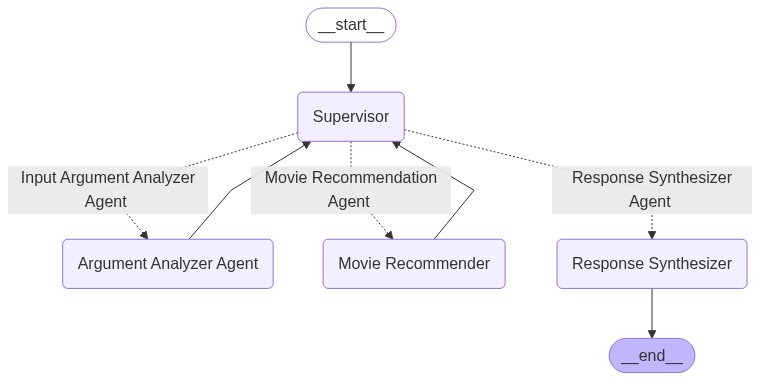

In [4]:
graph = StateGraph(AgentState)
graph.add_node("Supervisor", supervisor_agent.perform_task)
graph.add_node("Argument Analyzer Agent", argument_analyser_agent.perform_task)
graph.add_node("Movie Recommender", movie_recommendation_agent.perform_task)
graph.add_node("Response Synthesizer", response_synthesizer_agent.perform_task)

conditional_map = {
    "Input Argument Analyzer Agent": "Argument Analyzer Agent",
    "Movie Recommendation Agent": "Movie Recommender",
    "Response Synthesizer Agent": "Response Synthesizer"
}

graph.add_edge(START, "Supervisor")
graph.add_conditional_edges("Supervisor", lambda x: x["next"], conditional_map)
graph.add_edge("Argument Analyzer Agent", "Supervisor")
graph.add_edge("Movie Recommender", "Supervisor")
graph.add_edge("Response Synthesizer", END)

app_graph = graph.compile()
Image(app_graph.get_graph().draw_mermaid_png())

In [5]:
async def invoke_agent(user_message_history: dict, verbose=False):
    if verbose:
            print("======================================================\n")
        
    input_prompt = []
    for message in user_message_history:
        splitted_message = message.split(" -> ")
        key = splitted_message[0]
        value = splitted_message[1]
            
        if key == 'user':
            input_prompt.append(ChatMessage(role="user", content=value))
        elif key == 'ai':
            input_prompt.append(ChatMessage(role="assistant", content=value))
        else:
            pass

    if verbose:
        print("Input prompt: ", input_prompt, "\n")
    
    state = AgentState(
        messages=input_prompt
    )

    final_response = str()
    async for output in app_graph.astream(state):
        for key, value in output.items():
            if  verbose:
                print(f"Current agent: [{key}]")
            if "messages" in value:
                if verbose:
                    print("Agent response: ", value['messages'][-1].content)
                final_response = value['messages'][-1].content
            elif "next" in value:
                if verbose:
                    print(f"Next agent to call: {value['next']}")
            if verbose:
                print("-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*\n")


    if verbose:
        print("[Final respnose]: ", final_response)
    return final_response

In [ ]:
user_message_history = []
message_for_user = "Welcome to MovieGPT! How can I help you today?"

console = Console()
console.rule("[cyan]🎧 MusicGPT Chat Assistant[/cyan]")

while True:
    console.print(f"\n[cyan] MovieGPT:[/cyan] [bright_white]{message_for_user}[/bright_white]")
    user_input = Prompt.ask("[magenta]You[/magenta]")

    if user_input.lower() in ["exit", "quit", "bye"]:
        console.print("\n[green] Goodbye! Enjoy your movie![/green]")
        break

    user_message_history.append(f"ai -> {message_for_user}")
    user_message_history.append(f"user -> {user_input}")

    message_for_user = await invoke_agent(user_message_history, verbose=True)

─────────────────────────────────────────── 🎧 MusicGPT Chat Assistant ────────────────────────────────────────────

 MovieGPT: Welcome to MovieGPT! How can I help you today?

You:

 I want to see a movie.



Input prompt:  [ChatMessage(content='Welcome to MovieGPT! How can I help you today?', additional_kwargs={}, response_metadata={}, role='assistant'), ChatMessage(content='I want to see a movie.', additional_kwargs={}, response_metadata={}, role='user')] 

Current agent: [Supervisor]
Next agent to call: Input Argument Analyzer Agent
-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*

Current agent: [Argument Analyzer Agent]
Agent response:  More information is needed from the user. Please ask them: 'What genre of movie are you interested in?' and 'Any specific language preference for the movie?'
-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*

Current agent: [Supervisor]
Next agent to call: Response Synthesizer Agent
-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*

Current agent: [Response Synthesizer]
Agent response:  Great! To help me find the perfect movie for you, could you please tell me what genre you're interested in? Also, do you have any spec

...


Input prompt:  [ChatMessage(content='Welcome to MovieGPT! How can I help you today?', additional_kwargs={}, response_metadata={}, role='assistant'), ChatMessage(content='I want to see a movie.', additional_kwargs={}, response_metadata={}, role='user'), ChatMessage(content="Great! To help me find the perfect movie for you, could you please tell me what genre you're interested in? Also, do you have any specific language preference for the movie?", additional_kwargs={}, response_metadata={}, role='assistant'), ChatMessage(content='Chinese movie', additional_kwargs={}, response_metadata={}, role='user'), ChatMessage(content="Sure, I'd be happy to recommend a Chinese movie for you! To narrow down the options, could you please tell me what genre you're interested in? For example, are you in the mood for a comedy, drama, action, or perhaps something else?", additional_kwargs={}, response_metadata={}, role='assistant'), ChatMessage(content='something like Kungfu', additional_kwargs={}, respon

 MovieGPT: Great choice! Kung Fu movies are always exciting. To find the best match for you, could you please tell 
me if you have any specific year preference for the movie? For example, are you interested in classic Kung Fu 
movies from the 70s and 80s, or do you prefer more recent ones?

You:

 Anything is fine



Input prompt:  [ChatMessage(content='Welcome to MovieGPT! How can I help you today?', additional_kwargs={}, response_metadata={}, role='assistant'), ChatMessage(content='I want to see a movie.', additional_kwargs={}, response_metadata={}, role='user'), ChatMessage(content="Great! To help me find the perfect movie for you, could you please tell me what genre you're interested in? Also, do you have any specific language preference for the movie?", additional_kwargs={}, response_metadata={}, role='assistant'), ChatMessage(content='Chinese movie', additional_kwargs={}, response_metadata={}, role='user'), ChatMessage(content="Sure, I'd be happy to recommend a Chinese movie for you! To narrow down the options, could you please tell me what genre you're interested in? For example, are you in the mood for a comedy, drama, action, or perhaps something else?", additional_kwargs={}, response_metadata={}, role='assistant'), ChatMessage(content='something like Kungfu', additional_kwargs={}, respon